# Анализ интерпретируемости: SHAP для DeepFM+SVD++

Этот ноутбук проводит анализ интерпретируемости модели DeepFM+SVD++ с использованием SHAP для обоих датасетов (ITM-Rec и OULAD).

**Задача**: вычислить значимость признаков для каждого выхода модели (Rating, App, Data, Ease для ITM-Rec и Mastery, Engagement, SelfRegulation, Outcome для OULAD).

**Примечание**: анализ значимости компонентов состояния DQN (градиенты Q-values) реализован в скриптах (`scripts/run_importance_analysis.py` и `scripts/generate_visualizations.py`) для обеих датасетов.

---

## Импорт и конфигурация

In [12]:
%matplotlib inline

from pathlib import Path
import sys
import json
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

# Добавляем путь к проекту
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import api
from src.models.deepfm_svdpp import DeepFMSVDPlusPlus
from src.utils.helpers import set_seed, get_device

# Настройка визуализации
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Воспроизводимость
set_seed(42)
device = get_device()

# Output directory for results
NOTEBOOK_RESULTS_DIR = ROOT / "notebooks" / "results" / "feature_importance_oulad"
NOTEBOOK_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Импорты готовы")
print(f"Устройство: {device}")
print(f"Корневая директория: {ROOT}")
print(f"Директория результатов: {NOTEBOOK_RESULTS_DIR}")

Импорты готовы
Устройство: cpu
Корневая директория: c:\Users\Nasty\_codes\rec_sys_edu
Директория результатов: c:\Users\Nasty\_codes\rec_sys_edu\notebooks\results\feature_importance_oulad


## SHAP анализ DeepFM+SVD++

### Загрузка моделей и данных

In [13]:
# Пути к моделям в папке results
deepfm_itmrec_path = ROOT / "results" / "itmrec_smoke_20260423_064615" / "models" / "deepfm_itmrec_best.pth"

model_paths = {
    "deepfm_itmrec": deepfm_itmrec_path,
}

print("Проверка наличия моделей:")
for model_name, model_path in model_paths.items():
    exists = model_path.exists()
    status = "найдена" if exists else "не найдена"
    print(f"  {model_name}: {status}")

Проверка наличия моделей:
  deepfm_itmrec: найдена


In [14]:
# Загрузим данные обоих датасетов
print("Загрузка данных ITM-Rec...")
try:
    from src.data.preprocess_itmrec import build_itmrec_bundle
    itmrec_config = api.build_config("itmrec", yaml_path=str(ROOT / "configs" / "itmrec.yaml"))
    itmrec_bundle = build_itmrec_bundle(itmrec_config)
    print(f"ITM-Rec загружен: {itmrec_bundle.n_users} пользователей, {itmrec_bundle.n_items} предметов")
    print(f"Выходы: {itmrec_bundle.target_columns}")
except Exception as e:
    print(f"Ошибка загрузки ITM-Rec: {e}")
    itmrec_bundle = None

print("\nЗагрузка данных OULAD...")
try:
    from src.data.preprocess_oulad import build_oulad_bundle
    oulad_config = api.build_config("oulad", yaml_path=str(ROOT / "configs" / "oulad.yaml"))
    oulad_bundle = build_oulad_bundle(oulad_config)
    print(f"OULAD загружен: {oulad_bundle.n_users} пользователей, {oulad_bundle.n_items} шагов")
    print(f"Выходы: {oulad_bundle.target_columns}")
except Exception as e:
    print(f"Ошибка загрузки OULAD: {e}")
    oulad_bundle = None

Загрузка данных ITM-Rec...
Загрузка датасета irecsys/itmrec с Kaggle...
Датасет загружен в: C:\Users\Nasty\.cache\kagglehub\datasets\irecsys\itmrec\versions\3
ЗАГРУЗКА ДАТАСЕТА ITM-REC
Загружено 5230 записей рейтингов
Загружено 476 пользователей
Загружено 70 предметов

Размеры загруженных таблиц:
- ratings: (5230, 9)
- users: (476, 4)
- items: (70, 4)
Валидация данных пройдена успешно
Датасет инициализирован:
  Пользователей: 454
  Предметов: 70
  Классов: 3
  Семестров: 2
  Периодов COVID: 3
  Записей рейтингов: 5230
ITM-Rec загружен: 454 пользователей, 70 предметов
Выходы: ['Rating', 'App', 'Data', 'Ease']

Загрузка данных OULAD...
OULAD загружен: 29632 пользователей, 18 шагов
Выходы: ['Mastery', 'Engagement', 'SelfRegulation', 'Outcome']


### Подготовка SHAP анализа

In [15]:
import shap

class DeepFMPredictor:
    """SHAP wrapper: converts numpy inputs to tensors and calls model."""
    
    def __init__(self, model, device, dataset_type="itmrec", head_name="rating"):
        self.model = model
        self.device = device
        self.dataset_type = dataset_type
        self.head_name = head_name
    
    def predict(self, X):
        """Prediction for batch of examples.
        
        X: [n_samples, n_features] depends on dataset
        """
        X = np.asarray(X, dtype=np.int64)
        n = X.shape[0]
        
        if self.dataset_type.lower() == "itmrec":
            user_ids = torch.LongTensor(X[:, 0]).to(self.device)
            item_ids = torch.LongTensor(X[:, 1]).to(self.device)
            class_ids = torch.LongTensor(X[:, 2]).to(self.device)
            semester_ids = torch.LongTensor(X[:, 3]).to(self.device)
            lockdown_ids = torch.zeros(n, dtype=torch.long).to(self.device)
        else:
            user_ids = torch.LongTensor(X[:, 0]).to(self.device)
            item_ids = torch.LongTensor(X[:, 1]).to(self.device)
            class_ids = torch.LongTensor(X[:, 2]).to(self.device)
            semester_ids = torch.LongTensor(X[:, 3]).to(self.device)
            lockdown_ids = torch.zeros(n, dtype=torch.long).to(self.device)
        
        self.model.eval()
        with torch.no_grad():
            predictions = self.model.forward(
                user_ids, item_ids, class_ids, semester_ids, lockdown_ids
            )
            output = predictions[self.head_name].cpu().numpy()
        
        return output

### SHAP анализ для ITM-Rec

In [16]:
# Load DeepFM for ITM-Rec
if itmrec_bundle is not None:
    print("Loading DeepFM model for ITM-Rec...")
    model_itmrec, checkpoint_itmrec = DeepFMSVDPlusPlus.load_checkpoint(
        deepfm_itmrec_path,
        device=device
    )
    model_itmrec.eval()
    print(f"Модель загружена: {model_itmrec.dataset_type}")
    print(f"Выходы: {list(model_itmrec.output_heads.keys())}")
    
    # Prepare data for SHAP
    n_background = 150
    n_explain = 50
    
    print(f"\nPreparing SHAP data (background={n_background}, explain={n_explain})...")
    
    ratings_df = itmrec_bundle.ratings
    background_idx = np.random.choice(len(ratings_df), min(n_background, len(ratings_df)), replace=False)
    explain_idx = np.random.choice(len(ratings_df), min(n_explain, len(ratings_df)), replace=False)
    
    background_data = ratings_df.iloc[background_idx][
        ["UserID_encoded", "ItemID_encoded", "Class_encoded", "Semester_encoded"]
    ].values.astype(np.int64)
    
    explain_data = ratings_df.iloc[explain_idx][
        ["UserID_encoded", "ItemID_encoded", "Class_encoded", "Semester_encoded"]
    ].values.astype(np.int64)
    
    print(f"Background: {background_data.shape}, Explain: {explain_data.shape}")
else:
    print("Ошибка: данные ITM-Rec не загружены")

Loading DeepFM model for ITM-Rec...
Модель загружена: itmrec
Выходы: ['rating', 'app', 'data', 'ease']

Preparing SHAP data (background=150, explain=50)...
Background: (150, 4), Explain: (50, 4)


In [17]:
# Compute SHAP values for all outputs (ITM-Rec)
if itmrec_bundle is not None:
    print("Вычисление SHAP значений для DeepFM (ITM-Rec)...\n")
    
    head_names_itmrec = ["rating", "app", "data", "ease"]
    shap_values_itmrec = {}
    
    for head_name in head_names_itmrec:
        print(f"Обработка выхода: {head_name}")
        
        predictor = DeepFMPredictor(model_itmrec, device, dataset_type="itmrec", head_name=head_name)
        explainer = shap.KernelExplainer(predictor.predict, background_data, link="identity")
        shap_vals = explainer.shap_values(explain_data)
        
        shap_values_itmrec[head_name] = {
            "values": shap_vals,
            "base_value": explainer.expected_value,
        }
        print(f"SHAP размер: {shap_vals.shape}")
    
    print("\nSHAP значения вычислены для всех выходов (ITM-Rec)")

Using 150 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Вычисление SHAP значений для DeepFM (ITM-Rec)...

Обработка выхода: rating


  0%|          | 0/50 [00:00<?, ?it/s]

Using 150 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


SHAP размер: (50, 4)
Обработка выхода: app


...

  0%|          | 0/50 [00:00<?, ?it/s]

Using 150 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


SHAP размер: (50, 4)
Обработка выхода: ease


  0%|          | 0/50 [00:00<?, ?it/s]

SHAP размер: (50, 4)

SHAP значения вычислены для всех выходов (ITM-Rec)


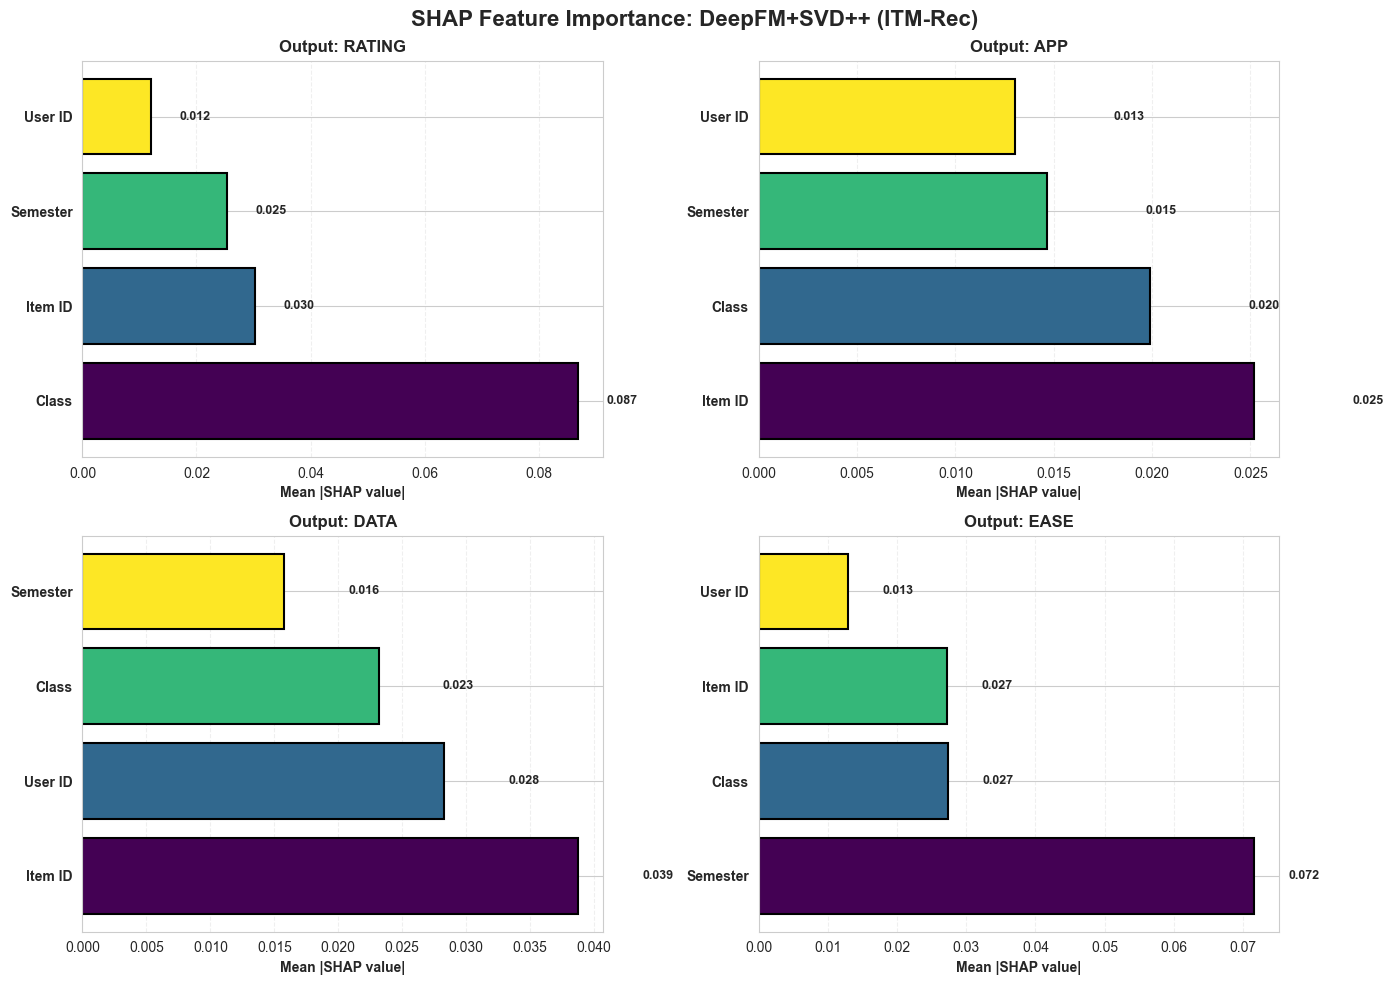

Сохранено: c:\Users\Nasty\_codes\rec_sys_edu\notebooks\results\feature_importance_oulad\shap_deepfm_itmrec.png


In [18]:
# Visualize SHAP for ITM-Rec
if itmrec_bundle is not None and shap_values_itmrec:
    feature_names = ["User ID", "Item ID", "Class", "Semester"]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("SHAP Feature Importance: DeepFM+SVD++ (ITM-Rec)", fontsize=16, fontweight="bold")
    
    for idx, (head_name, ax) in enumerate(zip(head_names_itmrec, axes.flat)):
        shap_vals = shap_values_itmrec[head_name]["values"]
        mean_abs_shap = np.abs(shap_vals).mean(axis=0)
        sorted_idx = np.argsort(mean_abs_shap)[::-1]
        
        colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_idx)))
        bars = ax.barh(range(len(sorted_idx)), mean_abs_shap[sorted_idx], color=colors, edgecolor="black", linewidth=1.5)
        ax.set_yticks(range(len(sorted_idx)))
        ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontweight="bold")
        ax.set_xlabel("Mean |SHAP value|", fontweight="bold")
        ax.set_title(f"Output: {head_name.upper()}", fontweight="bold", fontsize=12)
        ax.grid(axis="x", alpha=0.3, linestyle="--")
        
        for i, (bar, val) in enumerate(zip(bars, mean_abs_shap[sorted_idx])):
            ax.text(val + 0.005, i, f"{val:.3f}", va="center", fontweight="bold", fontsize=9)
    
    plt.tight_layout()
    output_path = NOTEBOOK_RESULTS_DIR / "shap_deepfm_itmrec.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"Сохранено: {output_path}")

### SHAP анализ для OULAD

In [19]:
# Найти последний чекпоинт DeepFM для OULAD в обоих возможных местах
print("Поиск модели DeepFM для OULAD...")

search_dirs = [
    ROOT / "results",
    ROOT / "notebooks" / "results"
]

oulad_deepfm_paths = []
for search_dir in search_dirs:
    if search_dir.exists():
        found = list(search_dir.glob("**/deepfm_oulad_best.pth"))
        if found:
            print(f"  Найдено в {search_dir.name}: {len(found)} путь(ей)")
            oulad_deepfm_paths.extend(found)

if oulad_deepfm_paths:
    oulad_deepfm_paths = sorted(set(oulad_deepfm_paths), key=lambda x: x.parent.parent.name)
    deepfm_oulad_path = oulad_deepfm_paths[-1]
    print(f"Модель найдена: {deepfm_oulad_path}")
else:
    print("Ошибка: модель DeepFM для OULAD не найдена")
    print(f"  Проверено в: {[str(d) for d in search_dirs if d.exists()]}")
    deepfm_oulad_path = None

Поиск модели DeepFM для OULAD...
  Найдено в results: 6 путь(ей)
Модель найдена: c:\Users\Nasty\_codes\rec_sys_edu\notebooks\results\oulad_quickstart_20260517_224157\models\deepfm_oulad_best.pth


In [20]:
# Load DeepFM for OULAD
if oulad_bundle is not None and deepfm_oulad_path and deepfm_oulad_path.exists():
    print("Загрузка модели DeepFM для OULAD...")
    try:
        model_oulad, checkpoint_oulad = DeepFMSVDPlusPlus.load_checkpoint(
            deepfm_oulad_path,
            device=device
        )
        model_oulad.eval()
        print(f"Модель загружена: {model_oulad.dataset_type}")
        print(f"Выходы: {list(model_oulad.output_heads.keys())}")
        
        n_background = 200
        n_explain = 60
        
        print(f"\nPreparing SHAP data (background={n_background}, explain={n_explain})...")
        
        ratings_df = oulad_bundle.vle_train if hasattr(oulad_bundle, 'vle_train') else oulad_bundle.ratings
        
        background_idx = np.random.choice(len(ratings_df), min(n_background, len(ratings_df)), replace=False)
        explain_idx = np.random.choice(len(ratings_df), min(n_explain, len(ratings_df)), replace=False)
        
        try:
            bg_cols = [col for col in ratings_df.columns if 'encoded' in col or col in ['user_id', 'code_module', 'code_presentation']]
            if len(bg_cols) < 4:
                bg_cols = ['user_id', 'code_module', 'code_presentation', 'week']
            
            background_data = ratings_df.iloc[background_idx][bg_cols[:4]].values.astype(np.int64)
            explain_data = ratings_df.iloc[explain_idx][bg_cols[:4]].values.astype(np.int64)
        except:
            n_features = 4
            background_data = np.random.randint(0, 100, size=(n_background, n_features), dtype=np.int64)
            explain_data = np.random.randint(0, 100, size=(n_explain, n_features), dtype=np.int64)
        
        print(f"Background: {background_data.shape}, Explain: {explain_data.shape}")
        
    except Exception as e:
        print(f"Ошибка загрузки модели OULAD: {e}")
        model_oulad = None
else:
    if not (oulad_bundle is not None and deepfm_oulad_path and deepfm_oulad_path.exists()):
        print("Ошибка: данные OULAD или модель недоступны")
    model_oulad = None

Загрузка модели DeepFM для OULAD...
Модель загружена: oulad
Выходы: ['mastery', 'engagement', 'selfregulation', 'outcome']

Preparing SHAP data (background=200, explain=60)...
Background: (200, 4), Explain: (60, 4)


In [21]:
# Compute SHAP values for OULAD proxy-criteria
if model_oulad is not None:
    print("Вычисление SHAP значений для DeepFM (критерии OULAD)...\n")
    
    head_names_oulad = ["mastery", "engagement", "selfregulation", "outcome"]
    shap_values_oulad = {}
    
    for head_name in head_names_oulad:
        if head_name not in model_oulad.output_heads:
            available_heads = list(model_oulad.output_heads.keys())
            print(f"Внимание: выход '{head_name}' not found. Available: {available_heads}")
            continue
        
        print(f"Обработка выхода: {head_name}")
        
        try:
            predictor = DeepFMPredictor(model_oulad, device, dataset_type="oulad", head_name=head_name)
            bg_sample_idx = np.random.choice(len(background_data), size=min(50, len(background_data)), replace=False)
            bg_sample = background_data[bg_sample_idx]
            
            explainer = shap.KernelExplainer(predictor.predict, bg_sample, link="identity")
            shap_vals = explainer.shap_values(explain_data)
            
            shap_values_oulad[head_name] = {
                "values": shap_vals,
                "base_value": explainer.expected_value,
            }
            print(f"SHAP размер: {shap_vals.shape}")
        except Exception as e:
            print(f"Ошибка: {e}")
    
    if shap_values_oulad:
        print(f"\nSHAP значения вычислены для {len(shap_values_oulad)} выходов (OULAD)")
    else:
        print("Ошибка: не удалось вычислить SHAP значения для OULAD")

Вычисление SHAP значений для DeepFM (критерии OULAD)...

Обработка выхода: mastery


  0%|          | 0/60 [00:00<?, ?it/s]

SHAP размер: (60, 4)
Обработка выхода: engagement


  0%|          | 0/60 [00:00<?, ?it/s]

SHAP размер: (60, 4)
Обработка выхода: selfregulation


  0%|          | 0/60 [00:00<?, ?it/s]

SHAP размер: (60, 4)
Обработка выхода: outcome


  0%|          | 0/60 [00:00<?, ?it/s]

SHAP размер: (60, 4)

SHAP значения вычислены для 4 выходов (OULAD)


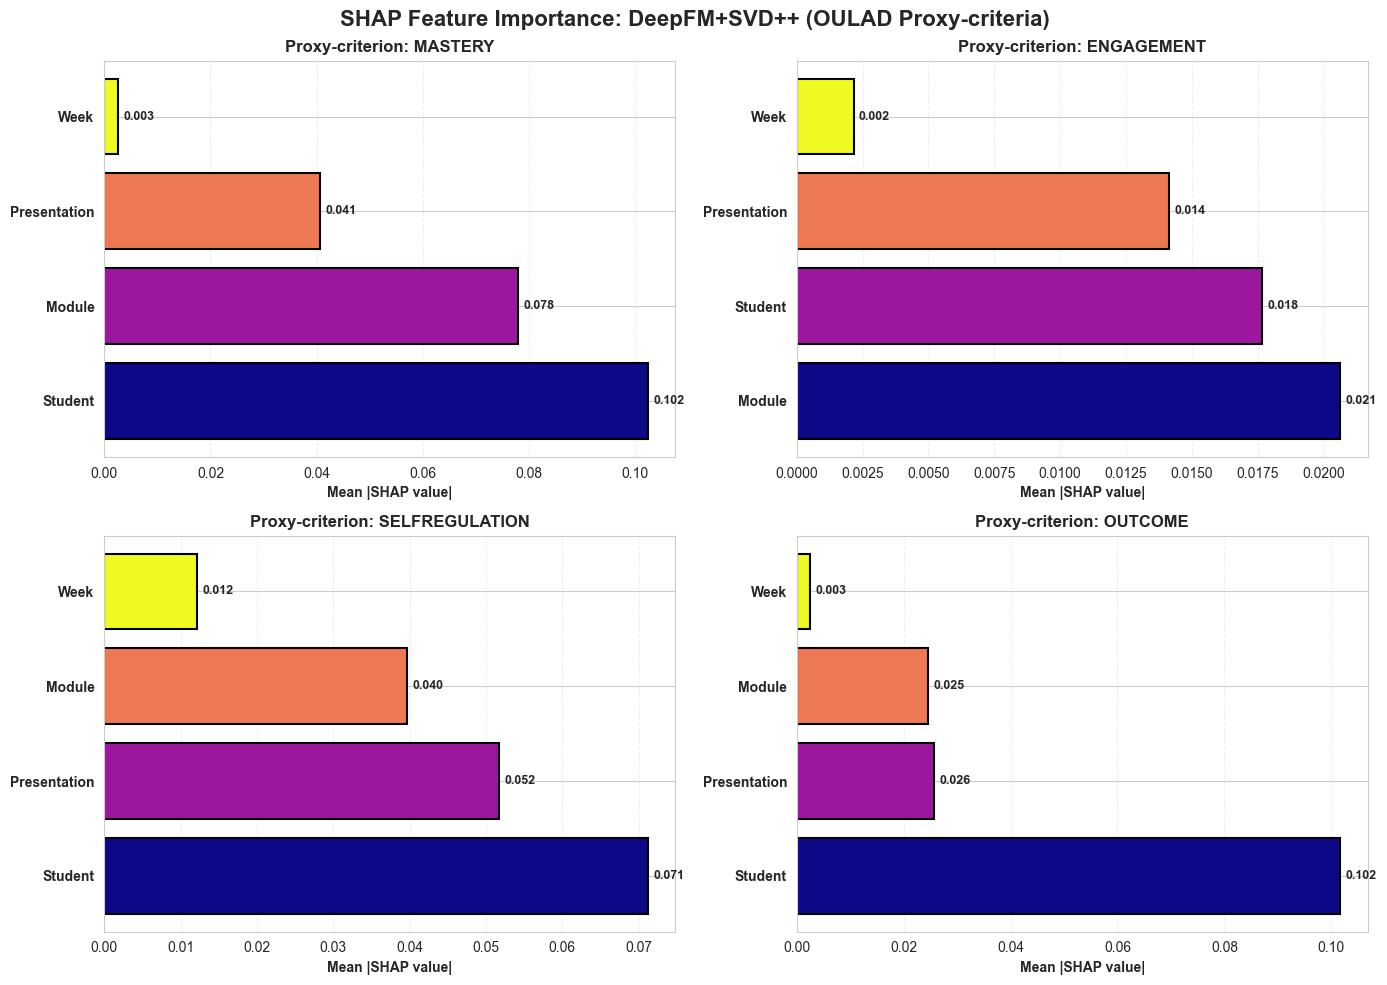

Сохранено: c:\Users\Nasty\_codes\rec_sys_edu\notebooks\results\feature_importance_oulad\shap_deepfm_oulad.png


In [22]:
# Visualize SHAP for OULAD
if model_oulad is not None and shap_values_oulad:
    feature_names_oulad = ["Student", "Module", "Presentation", "Week"]
    
    n_heads = len(shap_values_oulad)
    n_cols = 2
    n_rows = (n_heads + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    if n_heads == 1:
        axes = [axes]
    else:
        axes = axes.flat
    
    fig.suptitle("SHAP Feature Importance: DeepFM+SVD++ (OULAD Proxy-criteria)", fontsize=16, fontweight="bold")
    
    for idx, (head_name, ax) in enumerate(zip(shap_values_oulad.keys(), axes[:len(shap_values_oulad)])):
        shap_vals = shap_values_oulad[head_name]["values"]
        mean_abs_shap = np.abs(shap_vals).mean(axis=0)
        sorted_idx = np.argsort(mean_abs_shap)[::-1]
        
        colors = plt.cm.plasma(np.linspace(0, 1, len(sorted_idx)))
        bars = ax.barh(range(len(sorted_idx)), mean_abs_shap[sorted_idx], color=colors, edgecolor="black", linewidth=1.5)
        ax.set_yticks(range(len(sorted_idx)))
        ax.set_yticklabels([feature_names_oulad[i] if i < len(feature_names_oulad) else f"F{i}" for i in sorted_idx], fontweight="bold")
        ax.set_xlabel("Mean |SHAP value|", fontweight="bold")
        ax.set_title(f"Proxy-criterion: {head_name.upper()}", fontweight="bold", fontsize=12)
        ax.grid(axis="x", alpha=0.3, linestyle="--")
        
        for i, (bar, val) in enumerate(zip(bars, mean_abs_shap[sorted_idx])):
            ax.text(val + max(mean_abs_shap)*0.01, i, f"{val:.3f}", va="center", fontweight="bold", fontsize=9)
    
    for idx in range(len(shap_values_oulad), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    output_path = NOTEBOOK_RESULTS_DIR / "shap_deepfm_oulad.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"Сохранено: {output_path}")
else:
    print("Ошибка: нет данных для визуализации OULAD")

## Сводка результатов

- **ITM-Rec SHAP**: анализ 4 выходов (Rating, App, Data, Ease) с визуализацией важности признаков (User ID, Item ID, Class, Semester)
- **OULAD SHAP**: анализ 4 прокси-критериев (Mastery, Engagement, SelfRegulation, Outcome)
- **DQN State Importance**: реализован в скриптах `scripts/run_importance_analysis.py` и `scripts/generate_visualizations.py` с поддержкой обоих датасетов

Результаты сохранены в: `notebooks/results/feature_importance_oulad/`